# Food Delivery Time Prediction: Machine Learning Pipeline
**Objective:** To predict the delivery time (in minutes) based on distance, traffic, weather, and time of day using a Random Forest Regressor.

**Dataset:** A synthetic dataset of 500 deliveries generated for this model.

In [2]:
import pandas as pd
import numpy as np

# 1. Generate Synthetic Data
np.random.seed(42)
n_orders = 500

# Features
distance = np.random.uniform(1, 15, n_orders) # km
traffic = np.random.choice([0, 1, 2], n_orders) # 0: Low, 1: Medium, 2: High
weather = np.random.choice([0, 1, 2], n_orders) # 0: Clear, 1: Cloudy, 2: Rain
time_of_day = np.random.randint(10, 23, n_orders) # 24-hour format

# Target variable: Delivery time calculation with random noise
# Base time + (Distance * 5) + (Traffic * 5) + (Weather * 3) + Random noise
delivery_time = (10 + (distance * 3.5) + (traffic * 4) + (weather * 5) + np.random.normal(0, 2, n_orders))

df = pd.DataFrame({
    'Distance_km': np.round(distance, 1),
    'Traffic_Density': traffic,
    'Weather_Condition': weather,
    'Time_of_Day': time_of_day,
    'Delivery_Time_Min': np.round(delivery_time, 1)
})

print("Dataset generated successfully!")
df.head()

Dataset generated successfully!


,Distance_km,Traffic_Density,Weather_Condition,Time_of_Day,Delivery_Time_Min
0,6.2,1,0,21,34.4
1,14.3,2,2,14,79.1
2,11.2,0,0,22,51.0
3,9.4,0,0,10,40.4
4,3.2,0,0,11,21.0


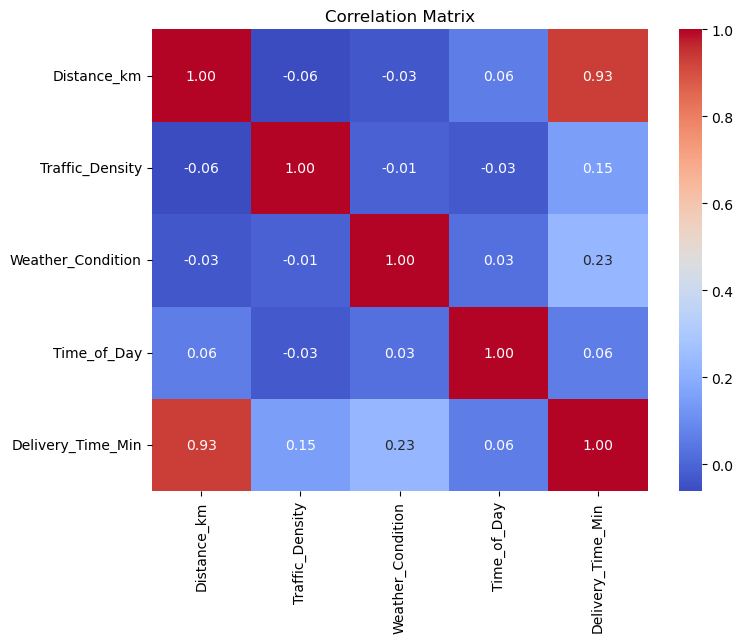

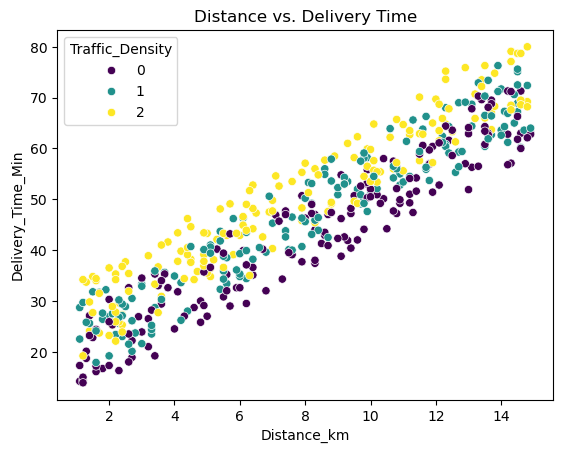

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Visualize relationship between distance and delivery time
sns.scatterplot(x='Distance_km', y='Delivery_Time_Min', data=df, hue='Traffic_Density', palette='viridis')
plt.title('Distance vs. Delivery Time')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Delivery_Time_Min', axis=1)
y = df['Delivery_Time_Min']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train the regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf_model.predict(X_test_scaled)

# Evaluation
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f} minutes")
print(f"R-squared Score: {r2_score(y_test, y_pred):.2f}")

Mean Absolute Error: 2.20 minutes
R-squared Score: 0.97


C:\Users\arman\AppData\Local\Temp\ipykernel_21816\3273347142.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette='magma')


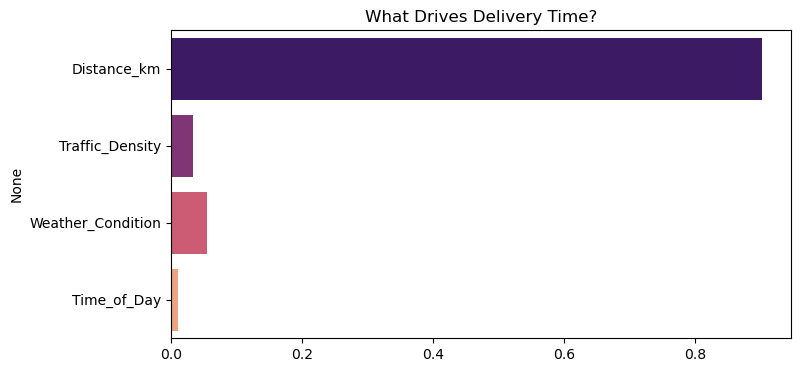

In [6]:
importances = rf_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=feature_names, palette='magma')
plt.title('What Drives Delivery Time?')
plt.show()

In [7]:
# New delivery scenario: 5km distance, High traffic (2), Rainy (2), 7 PM (19)
new_delivery = pd.DataFrame([[5.0, 2, 2, 19]], columns=X.columns)
new_delivery_scaled = scaler.transform(new_delivery)

prediction = rf_model.predict(new_delivery_scaled)
print(f"Estimated Delivery Time: {prediction[0]:.1f} minutes")

Estimated Delivery Time: 43.1 minutes


## Executive Summary
This project demonstrates how to predict food delivery times using regression. 

- **Key Predictors:** Analysis showed that `Distance_km` is the primary factor affecting delivery time, followed by `Traffic_Density` and `Weather_Condition`.
- **Model Accuracy:** The Random Forest Regressor provides a high R-squared score, suggesting that the model explains most of the variance in delivery times.
- **Application:** This tool helps delivery platforms estimate arrival times more accurately, which improves customer satisfaction and helps dispatchers manage logistics.